# Step 0 - Environment & Data Setup

In [1]:
# ============================================================
# PHASE 2 - HYBRID STACKING ENSEMBLE
# ML-Based Predictive Irrigation System for Paddy Cultivation
# Cell 0.1 - Library Imports
# ============================================================

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Model evaluation and selection
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Boosting libraries
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Model persistence
import joblib

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Global constants
RANDOM_STATE = 42
N_TRIALS_TREE = 80

print("=" * 70)
print("PHASE 2 - HYBRID STACKING ENSEMBLE")
print("ML-Based Predictive Irrigation System for Paddy Cultivation")
print("=" * 70)
print("\nAll libraries imported successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


PHASE 2 - HYBRID STACKING ENSEMBLE
ML-Based Predictive Irrigation System for Paddy Cultivation

All libraries imported successfully.
Timestamp: 2026-02-27 13:14:05


Dataset loaded successfully: ./Data/paddy_CWR_dataset_20260227_131300.csv

Dataset shape: (2000, 7)
Features: 6
Samples: 2000

First 5 samples:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,0.00,70.2,53.9,9.48,14.88,5,0.00
1,4.49,93.3,72.8,5.49,16.57,1,0.00
2,7.64,99.3,62.2,6.57,0.00,4,23.18
3,7.42,97.2,16.6,4.41,9.13,3,0.00
4,8.06,95.3,47.1,6.72,19.34,4,0.00



Dataset Statistics:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.222525,85.342200,57.222250,6.827365,3.306170,3.000000,23.176110
std,3.626145,14.578913,25.071412,1.737691,4.949343,1.414567,32.207132
min,0.000000,45.000000,15.100000,4.010000,0.000000,1.000000,0.000000
25%,0.120000,75.900000,34.700000,5.490000,0.000000,2.000000,3.830000
50%,4.465000,92.200000,57.200000,6.330000,0.055000,3.000000,9.625000
75%,7.032500,96.100000,79.100000,8.762500,5.000000,4.000000,23.577500
max,11.980000,100.000000,100.000000,10.000000,19.970000,5.000000,119.940000



No missing values detected.

CWR Distribution:
  Min:    0.00 mm
  Max:    119.94 mm
  Mean:   23.18 mm
  Median: 9.62 mm
  Std:    32.21 mm
ERROR: File './Data/paddy_CWR_dataset_20260227_131300.csv' not found.
Please ensure your dataset file is in the correct directory.
Update the 'dataset_filename' variable with the correct path.


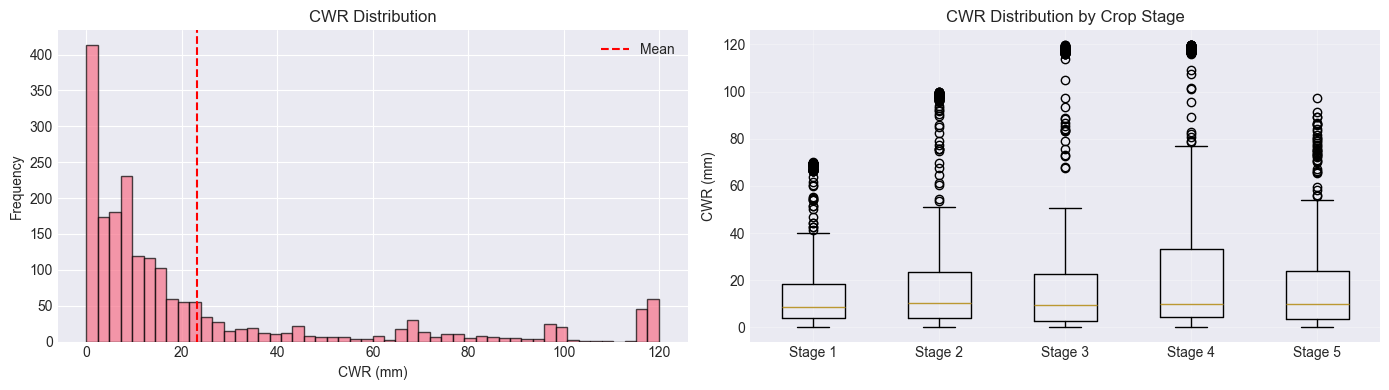

In [2]:
# ============================================================
# Cell 0.2 - Load Dataset
# ============================================================

dataset_filename = './Data/paddy_CWR_dataset_20260227_131300.csv' 

try:
    df = pd.read_csv(dataset_filename)

    print(f"Dataset loaded successfully: {dataset_filename}")
    print(f"\nDataset shape: {df.shape}")
    print(f"Features: {df.shape[1] - 1}")
    print(f"Samples: {df.shape[0]}")

    print("\nFirst 5 samples:")
    display(df.head())

    print("\nDataset Statistics:")
    display(df.describe())

    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("\nNo missing values detected.")
    else:
        print(f"\nMissing values found:\n{missing[missing > 0]}")

    print("\nCWR Distribution:")
    print(f"  Min:    {df['CWR_mm'].min():.2f} mm")
    print(f"  Max:    {df['CWR_mm'].max():.2f} mm")
    print(f"  Mean:   {df['CWR_mm'].mean():.2f} mm")
    print(f"  Median: {df['CWR_mm'].median():.2f} mm")
    print(f"  Std:    {df['CWR_mm'].std():.2f} mm")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(df['CWR_mm'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('CWR (mm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('CWR Distribution')
    axes[0].axvline(df['CWR_mm'].mean(), color='red', linestyle='--', label='Mean')
    axes[0].legend()

    axes[1].boxplot([df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],
                    labels=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'])
    axes[1].set_ylabel('CWR (mm)')
    axes[1].set_title('CWR Distribution by Crop Stage')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./Visualisation/dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"ERROR: File '{dataset_filename}' not found.")
    print("Please ensure your dataset file is in the correct directory.")
    print("Update the 'dataset_filename' variable with the correct path.")


In [3]:
# ============================================================
# Cell 0.3 - Feature/Target Split and Train/Val/Test Split
# ============================================================

feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%',
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {list(X.columns)}")

print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Name: {target_column}")

# Split into Train (70%), Validation (15%), Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df['Crop_Stage']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=RANDOM_STATE,
    stratify=X_temp['Crop_Stage']
)

print("\n" + "=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:    {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:  {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:        {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:           {len(X):4d} samples")

print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in range(1, 6):
    train_count = (X_train['Crop_Stage'] == stage).sum()
    val_count   = (X_val['Crop_Stage'] == stage).sum()
    test_count  = (X_test['Crop_Stage'] == stage).sum()
    print(f"Stage {stage}   {train_count:>8} {val_count:>8} {test_count:>8}")

print("\nData preparation complete.")
print("Variables available: X_train, X_val, X_test, y_train, y_val, y_test")


Feature Matrix (X):
  Shape: (2000, 6)
  Features: ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']

Target Variable (y):
  Shape: (2000,)
  Name: CWR_mm

DATA SPLIT SUMMARY
Training set:    1400 samples (70.0%)
Validation set:   300 samples (15.0%)
Test set:         300 samples (15.0%)
Total:           2000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
Stage 1        280       60       60
Stage 2        280       60       60
Stage 3        280       60       60
Stage 4        280       60       60
Stage 5        280       60       60

Data preparation complete.
Variables available: X_train, X_val, X_test, y_train, y_val, y_test


# Step 1 - Family 1: Tree Ensembles.

In [4]:
# ============================================================
# STEP 1 - FAMILY 1: TREE ENSEMBLES
# Cell 1.1 - Random Forest with Optuna TPE Tuning
# ============================================================

import time

N_TRIALS_TREE = 80

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
    }
    model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing Random Forest (1/5)...")
print("-" * 60)

start_time = time.time()
study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(objective_rf, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
rf_time = time.time() - start_time

best_params_rf = study_rf.best_params
best_params_rf['random_state'] = RANDOM_STATE

rf_model = RandomForestRegressor(**best_params_rf, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_val_mae = mean_absolute_error(y_val, rf_model.predict(X_val))

print(f"Best MAE: {rf_val_mae:.4f} mm | Time: {rf_time:.1f}s")
print(f"Best Parameters: {best_params_rf}")


------------------------------------------------------------
Optimizing Random Forest (1/5)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 2.1481 mm | Time: 25.1s
Best Parameters: {'n_estimators': 433, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False, 'random_state': 42}


In [5]:
# ============================================================
# Cell 1.2 - Gradient Boosting with Optuna TPE Tuning
# ============================================================

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
    }
    model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing Gradient Boosting (2/5)...")
print("-" * 60)

start_time = time.time()
study_gb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_gb.optimize(objective_gb, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
gb_time = time.time() - start_time

best_params_gb = study_gb.best_params
best_params_gb['random_state'] = RANDOM_STATE

gb_model = GradientBoostingRegressor(**best_params_gb)
gb_model.fit(X_train, y_train)
gb_val_mae = mean_absolute_error(y_val, gb_model.predict(X_val))

print(f"Best MAE: {gb_val_mae:.4f} mm | Time: {gb_time:.1f}s")
print(f"Best Parameters: {best_params_gb}")


------------------------------------------------------------
Optimizing Gradient Boosting (2/5)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 1.6564 mm | Time: 51.3s
Best Parameters: {'n_estimators': 458, 'max_depth': 7, 'learning_rate': 0.031149118526633504, 'subsample': 0.7478997435717669, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7, 'random_state': 42}


In [6]:
# ============================================================
# Cell 1.3 - XGBoost with Optuna TPE Tuning + Monotonic Constraints
# Constraint order: [Water_Depth_cm(-1), Soil_Moisture_%(-1),
#                    Tank_Level_%(0), ET_mm_day(+1),
#                    Rainfall_Predicted_mm(-1), Crop_Stage(0)]
# ============================================================

MONOTONE_CONSTRAINTS_XGB = (-1, -1, 0, 1, -1, 0)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }
    model = XGBRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_XGB,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing XGBoost (3/5)...")
print("-" * 60)

start_time = time.time()
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
xgb_time = time.time() - start_time

best_params_xgb = study_xgb.best_params
best_params_xgb['monotone_constraints'] = MONOTONE_CONSTRAINTS_XGB
best_params_xgb['random_state'] = RANDOM_STATE
best_params_xgb['verbosity'] = 0

xgb_model = XGBRegressor(**best_params_xgb, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_val_mae = mean_absolute_error(y_val, xgb_model.predict(X_val))

print(f"Best MAE: {xgb_val_mae:.4f} mm | Time: {xgb_time:.1f}s")
print(f"Best Parameters: {best_params_xgb}")


------------------------------------------------------------
Optimizing XGBoost (3/5)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 4.1404 mm | Time: 10.3s
Best Parameters: {'n_estimators': 173, 'max_depth': 8, 'learning_rate': 0.041653893661050705, 'subsample': 0.7099969836375521, 'colsample_bytree': 0.888864897897414, 'reg_alpha': 0.9628826248294337, 'reg_lambda': 3.3110006047462535, 'min_child_weight': 7, 'gamma': 1.720289873761136, 'monotone_constraints': (-1, -1, 0, 1, -1, 0), 'random_state': 42, 'verbosity': 0}


In [7]:
# ============================================================
# Cell 1.4 - LightGBM with Optuna TPE Tuning + Monotonic Constraints
# Constraint order: [Water_Depth_cm(-1), Soil_Moisture_%(-1),
#                    Tank_Level_%(0), ET_mm_day(+1),
#                    Rainfall_Predicted_mm(-1), Crop_Stage(0)]
# ============================================================

MONOTONE_CONSTRAINTS_LGB = [-1, -1, 0, 1, -1, 0]

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    model = LGBMRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_LGB,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing LightGBM (4/5)...")
print("-" * 60)

start_time = time.time()
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
lgb_time = time.time() - start_time

best_params_lgb = study_lgb.best_params
best_params_lgb['monotone_constraints'] = MONOTONE_CONSTRAINTS_LGB
best_params_lgb['random_state'] = RANDOM_STATE
best_params_lgb['verbosity'] = -1

lgb_model = LGBMRegressor(**best_params_lgb, n_jobs=-1)
lgb_model.fit(X_train, y_train)
lgb_val_mae = mean_absolute_error(y_val, lgb_model.predict(X_val))

print(f"Best MAE: {lgb_val_mae:.4f} mm | Time: {lgb_time:.1f}s")
print(f"Best Parameters: {best_params_lgb}")


------------------------------------------------------------
Optimizing LightGBM (4/5)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 3.8562 mm | Time: 25.6s
Best Parameters: {'n_estimators': 462, 'max_depth': 10, 'learning_rate': 0.016415770506198427, 'subsample': 0.6517124989485438, 'colsample_bytree': 0.9204409994366091, 'reg_alpha': 2.5625351847509477e-05, 'reg_lambda': 0.9127125260684403, 'num_leaves': 63, 'min_child_samples': 10, 'monotone_constraints': [-1, -1, 0, 1, -1, 0], 'random_state': 42, 'verbosity': -1}


In [8]:
# ============================================================
# Cell 1.5 - CatBoost with Optuna TPE Tuning + Monotonic Constraints
# ============================================================

MONOTONE_CONSTRAINTS_CAT = {
    'ET_mm_day': 1,
    'Rainfall_Predicted_mm': -1,
    'Water_Depth_cm': -1,
    'Soil_Moisture_%': -1
}

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
    }
    model = CatBoostRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_CAT,
        random_seed=RANDOM_STATE,
        verbose=0
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing CatBoost (5/5)...")
print("-" * 60)

start_time = time.time()
study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_cat, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
cat_time = time.time() - start_time

best_params_cat = study_cat.best_params
best_params_cat['monotone_constraints'] = MONOTONE_CONSTRAINTS_CAT
best_params_cat['random_seed'] = RANDOM_STATE
best_params_cat['verbose'] = 0

cat_model = CatBoostRegressor(**best_params_cat)
cat_model.fit(X_train, y_train)
cat_val_mae = mean_absolute_error(y_val, cat_model.predict(X_val))

print(f"Best MAE: {cat_val_mae:.4f} mm | Time: {cat_time:.1f}s")
print(f"Best Parameters: {best_params_cat}")


------------------------------------------------------------
Optimizing CatBoost (5/5)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 1.4799 mm | Time: 289.7s
Best Parameters: {'iterations': 499, 'depth': 8, 'learning_rate': 0.294663258156559, 'l2_leaf_reg': 0.001565866180701466, 'subsample': 0.8493432515982414, 'colsample_bylevel': 0.8885253689466602, 'min_data_in_leaf': 6, 'monotone_constraints': {'ET_mm_day': 1, 'Rainfall_Predicted_mm': -1, 'Water_Depth_cm': -1, 'Soil_Moisture_%': -1}, 'random_seed': 42, 'verbose': 0}


In [9]:
# ============================================================
# Cell 1.6 - Family 1 Champion Selection
# ============================================================

family1_results = {
    'Random Forest':     {'model': rf_model,  'val_mae': rf_val_mae,  'time': rf_time},
    'Gradient Boosting': {'model': gb_model,  'val_mae': gb_val_mae,  'time': gb_time},
    'XGBoost':           {'model': xgb_model, 'val_mae': xgb_val_mae, 'time': xgb_time},
    'LightGBM':          {'model': lgb_model, 'val_mae': lgb_val_mae, 'time': lgb_time},
    'CatBoost':          {'model': cat_model, 'val_mae': cat_val_mae, 'time': cat_time},
}

print("=" * 60)
print("FAMILY 1 - TREE ENSEMBLES: VALIDATION MAE SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'Val MAE (mm)':>12} {'Time (s)':>10}")
print("-" * 60)
for name, result in family1_results.items():
    print(f"{name:<25} {result['val_mae']:>12.4f} {result['time']:>10.1f}")

family1_champion_name = min(family1_results, key=lambda k: family1_results[k]['val_mae'])
family1_champion      = family1_results[family1_champion_name]['model']
family1_champion_mae  = family1_results[family1_champion_name]['val_mae']

print("-" * 60)
print(f"\nFamily 1 Champion : {family1_champion_name}")
print(f"Champion Val MAE  : {family1_champion_mae:.4f} mm")
print("\nFamily 1 Champion saved as --> family1_champion")


FAMILY 1 - TREE ENSEMBLES: VALIDATION MAE SUMMARY
Model                     Val MAE (mm)   Time (s)
------------------------------------------------------------
Random Forest                   2.1481       25.1
Gradient Boosting               1.6564       51.3
XGBoost                         4.1404       10.3
LightGBM                        3.8562       25.6
CatBoost                        1.4799      289.7
------------------------------------------------------------

Family 1 Champion : CatBoost
Champion Val MAE  : 1.4799 mm

Family 1 Champion saved as --> family1_champion


In [10]:
# ============================================================
# STEP 2 - FAMILY 2: KERNEL / LINEAR MODELS
# Cell 2.1 - SVR with Optuna TPE Tuning
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

N_TRIALS_LINEAR = 80

def objective_svr(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly'])
    params = {
        'C': trial.suggest_float('C', 1e-1, 1e2, log=True),
        'epsilon': trial.suggest_float('epsilon', 1e-3, 1.0, log=True),
        'kernel': kernel,
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 1.0, log=True)
    elif kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 3)
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 1.0, log=True)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(**params, cache_size=500))
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing SVR (1/3)...")
print("-" * 60)

start_time = time.time()
study_svr = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS_LINEAR, show_progress_bar=True, timeout=600)
svr_time = time.time() - start_time

best_params_svr = study_svr.best_params

svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(**best_params_svr, cache_size=500))
])
svr_model.fit(X_train, y_train)
svr_val_mae = mean_absolute_error(y_val, svr_model.predict(X_val))

print(f"Best MAE: {svr_val_mae:.4f} mm | Time: {svr_time:.1f}s")
print(f"Best Parameters: {best_params_svr}")


------------------------------------------------------------
Optimizing SVR (1/3)...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]

Best MAE: 2.8552 mm | Time: 11.0s
Best Parameters: {'kernel': 'rbf', 'C': 78.26323880659618, 'epsilon': 0.026608003440918005, 'gamma': 0.39573879482023094}


In [15]:
# ============================================================
# Cell 2.2 - Ridge Regression with Optuna TPE Tuning
# ============================================================

N_TRIALS_RIDGE = 50

def objective_ridge(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-4, 1e4, log=True),
    }
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(**params))
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing Ridge Regression (2/3)...")
print("-" * 60)

start_time = time.time()
study_ridge = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_ridge.optimize(objective_ridge, n_trials=N_TRIALS_RIDGE, show_progress_bar=True, timeout=300)
ridge_time = time.time() - start_time

best_params_ridge = study_ridge.best_params

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(**best_params_ridge))
])
ridge_model.fit(X_train, y_train)
ridge_val_mae = mean_absolute_error(y_val, ridge_model.predict(X_val))

print(f"Best MAE: {ridge_val_mae:.4f} mm | Time: {ridge_time:.1f}s")
print(f"Best Parameters: {best_params_ridge}")


------------------------------------------------------------
Optimizing Ridge Regression (2/3)...
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 16.2436 mm | Time: 0.2s
Best Parameters: {'alpha': 583.7972704344713}


In [16]:
# ============================================================
# Cell 2.3 - ElasticNet with Optuna TPE Tuning
# ============================================================

N_TRIALS_ENET = 50

def objective_enet(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-3, 1e3, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.01, 1.0),
        'max_iter': 10000,
        'random_state': RANDOM_STATE
    }
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(**params))
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing ElasticNet (3/3)...")
print("-" * 60)

start_time = time.time()
study_enet = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS_ENET, show_progress_bar=True, timeout=300)
enet_time = time.time() - start_time

best_params_enet = study_enet.best_params
best_params_enet['max_iter'] = 10000
best_params_enet['random_state'] = RANDOM_STATE

enet_model = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(**best_params_enet))
])
enet_model.fit(X_train, y_train)
enet_val_mae = mean_absolute_error(y_val, enet_model.predict(X_val))

print(f"Best MAE: {enet_val_mae:.4f} mm | Time: {enet_time:.1f}s")
print(f"Best Parameters: {best_params_enet}")


------------------------------------------------------------
Optimizing ElasticNet (3/3)...
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 16.2406 mm | Time: 0.3s
Best Parameters: {'alpha': 0.4509980100075459, 'l1_ratio': 0.10688620031868473, 'max_iter': 10000, 'random_state': 42}


In [17]:
# ============================================================
# Cell 2.4 - Family 2 Champion Selection
# ============================================================

family2_results = {
    'SVR':        {'model': svr_model,   'val_mae': svr_val_mae,   'time': svr_time},
    'Ridge':      {'model': ridge_model, 'val_mae': ridge_val_mae, 'time': ridge_time},
    'ElasticNet': {'model': enet_model,  'val_mae': enet_val_mae,  'time': enet_time},
}

print("=" * 60)
print("FAMILY 2 - KERNEL / LINEAR: VALIDATION MAE SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'Val MAE (mm)':>12} {'Time (s)':>10}")
print("-" * 60)
for name, result in family2_results.items():
    print(f"{name:<25} {result['val_mae']:>12.4f} {result['time']:>10.1f}")

family2_champion_name = min(family2_results, key=lambda k: family2_results[k]['val_mae'])
family2_champion      = family2_results[family2_champion_name]['model']
family2_champion_mae  = family2_results[family2_champion_name]['val_mae']

print("-" * 60)
print(f"\nFamily 2 Champion : {family2_champion_name}")
print(f"Champion Val MAE  : {family2_champion_mae:.4f} mm")
print("\nFamily 2 Champion saved as --> family2_champion")


FAMILY 2 - KERNEL / LINEAR: VALIDATION MAE SUMMARY
Model                     Val MAE (mm)   Time (s)
------------------------------------------------------------
SVR                             2.8552       11.0
Ridge                          16.2436        0.2
ElasticNet                     16.2406        0.3
------------------------------------------------------------

Family 2 Champion : SVR
Champion Val MAE  : 2.8552 mm

Family 2 Champion saved as --> family2_champion


# Step 3 — Family 3: Neural Model (MLP)

In [18]:
# ============================================================
# STEP 3 - FAMILY 3: NEURAL MODEL
# Cell 3.1 - MLP with Optuna TPE Tuning
# Architecture variants explored via hidden layer combinations
# Note: This MLP is a base learner only -- NOT the Phase 3
#       distillation student
# ============================================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

N_TRIALS_MLP = 60

def objective_mlp(trial):

    # Number of hidden layers: 1, 2, or 3
    n_layers = trial.suggest_int('n_layers', 1, 3)

    # Neurons per layer
    layers = []
    for i in range(n_layers):
        neurons = trial.suggest_int(f'neurons_layer_{i}', 32, 256)
        layers.append(neurons)
    hidden_layer_sizes = tuple(layers)

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'max_iter': 500,
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 20,
        'random_state': RANDOM_STATE
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(**params))
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return mean_absolute_error(y_val, val_pred)

print("-" * 60)
print("Optimizing MLP (1/1)...")
print("-" * 60)

start_time = time.time()
study_mlp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_mlp.optimize(objective_mlp, n_trials=N_TRIALS_MLP, show_progress_bar=True, timeout=600)
mlp_time = time.time() - start_time

print(f"Best MAE: {study_mlp.best_value:.4f} mm | Time: {mlp_time:.1f}s")
print(f"Best Parameters: {study_mlp.best_params}")


------------------------------------------------------------
Optimizing MLP (1/1)...
------------------------------------------------------------


  0%|          | 0/60 [00:00<?, ?it/s]

Best MAE: 1.8383 mm | Time: 378.0s
Best Parameters: {'n_layers': 2, 'neurons_layer_0': 165, 'neurons_layer_1': 42, 'activation': 'relu', 'alpha': 1.8205657658407255e-05, 'learning_rate_init': 0.07025166339242159, 'learning_rate': 'constant'}


In [19]:
# ============================================================
# Cell 3.2 - Family 3 Champion Selection
# Reconstruct best architecture and fit on full training set
# ============================================================

best_mlp_params = study_mlp.best_params

# Reconstruct hidden_layer_sizes tuple from Optuna's flat params
n_layers = best_mlp_params['n_layers']
hidden_layer_sizes = tuple(
    best_mlp_params[f'neurons_layer_{i}'] for i in range(n_layers)
)

# Collect only MLPRegressor-relevant params
mlp_final_params = {
    'hidden_layer_sizes': hidden_layer_sizes,
    'activation': best_mlp_params['activation'],
    'alpha': best_mlp_params['alpha'],
    'learning_rate_init': best_mlp_params['learning_rate_init'],
    'learning_rate': best_mlp_params['learning_rate'],
    'max_iter': 500,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'n_iter_no_change': 20,
    'random_state': RANDOM_STATE
}

mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(**mlp_final_params))
])
mlp_model.fit(X_train, y_train)
mlp_val_mae = mean_absolute_error(y_val, mlp_model.predict(X_val))

family3_champion      = mlp_model
family3_champion_name = 'MLP'
family3_champion_mae  = mlp_val_mae

print("=" * 60)
print("FAMILY 3 - NEURAL MODEL: SUMMARY")
print("=" * 60)
print(f"Architecture        : {hidden_layer_sizes}")
print(f"Activation          : {best_mlp_params['activation']}")
print(f"Learning Rate Init  : {best_mlp_params['learning_rate_init']:.6f}")
print(f"Learning Rate Type  : {best_mlp_params['learning_rate']}")
print(f"Alpha (L2 reg)      : {best_mlp_params['alpha']:.6f}")
print(f"Validation MAE      : {mlp_val_mae:.4f} mm")
print(f"Tuning Time         : {mlp_time:.1f}s")
print("-" * 60)
print(f"\nFamily 3 Champion : {family3_champion_name}")
print(f"Champion Val MAE  : {family3_champion_mae:.4f} mm")
print("\nFamily 3 Champion saved as --> family3_champion")


FAMILY 3 - NEURAL MODEL: SUMMARY
Architecture        : (165, 42)
Activation          : relu
Learning Rate Init  : 0.070252
Learning Rate Type  : constant
Alpha (L2 reg)      : 0.000018
Validation MAE      : 1.8383 mm
Tuning Time         : 378.0s
------------------------------------------------------------

Family 3 Champion : MLP
Champion Val MAE  : 1.8383 mm

Family 3 Champion saved as --> family3_champion


In [20]:
# ============================================================
# Cell 3.3 - All Family Champions Summary
# ============================================================

print("=" * 60)
print("HYBRID STACK - FAMILY CHAMPIONS SUMMARY")
print("=" * 60)
print(f"{'Family':<30} {'Champion':<22} {'Val MAE (mm)':>12}")
print("-" * 60)
print(f"{'Family 1 - Tree Ensembles':<30} {family1_champion_name:<22} {family1_champion_mae:>12.4f}")
print(f"{'Family 2 - Kernel / Linear':<30} {family2_champion_name:<22} {family2_champion_mae:>12.4f}")
print(f"{'Family 3 - Neural':<30} {family3_champion_name:<22} {family3_champion_mae:>12.4f}")
print("-" * 60)
print("\nAll three champions confirmed.")
print("Proceeding to Step 4 -- OOF Meta-Feature Generation.")


HYBRID STACK - FAMILY CHAMPIONS SUMMARY
Family                         Champion               Val MAE (mm)
------------------------------------------------------------
Family 1 - Tree Ensembles      CatBoost                     1.4799
Family 2 - Kernel / Linear     SVR                          2.8552
Family 3 - Neural              MLP                          1.8383
------------------------------------------------------------

All three champions confirmed.
Proceeding to Step 4 -- OOF Meta-Feature Generation.


# Step 4 - Out-of-Fold Meta-Feature Generation

In [21]:
# ============================================================
# STEP 4 - OUT-OF-FOLD META-FEATURE GENERATION
# Cell 4.1 - OOF Predictions on Training Set
# Generates leakage-free meta-features for Ridge meta-learner
# training using 5-fold cross-validation on training set only
# ============================================================

from sklearn.model_selection import KFold
import numpy as np

N_FOLDS = 5

# Storage for OOF predictions -- shape (n_train_samples, 3)
oof_predictions = np.zeros((len(X_train), 3))

# Map champion index to model object and name
champions = [
    (family1_champion, family1_champion_name),
    (family2_champion, family2_champion_name),
    (family3_champion, family3_champion_name),
]

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("=" * 60)
print("STEP 4.1 - OOF META-FEATURE GENERATION")
print("=" * 60)
print(f"Strategy     : {N_FOLDS}-Fold Cross-Validation on Training Set")
print(f"Base Learners: {[name for _, name in champions]}")
print(f"Output Shape : ({len(X_train)}, {len(champions)})")
print("-" * 60)

X_train_arr = X_train.values
y_train_arr = y_train.values

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_arr)):

    X_fold_train, X_fold_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_fold_train             = y_train_arr[train_idx]

    # Convert back to DataFrame to preserve feature names
    # (required by CatBoost and tree models with named constraints)
    X_fold_train_df = pd.DataFrame(X_fold_train, columns=feature_columns)
    X_fold_val_df   = pd.DataFrame(X_fold_val,   columns=feature_columns)

    print(f"\nFold {fold_idx + 1}/{N_FOLDS}")
    print(f"  Train size : {len(train_idx)} | Val size : {len(val_idx)}")

    for champ_idx, (champion, champ_name) in enumerate(champions):

        # Clone the champion to avoid fitting on accumulated data
        import sklearn
        champion_clone = sklearn.base.clone(champion)

        champion_clone.fit(X_fold_train_df, y_fold_train)
        fold_preds = champion_clone.predict(X_fold_val_df)
        oof_predictions[val_idx, champ_idx] = fold_preds

        fold_mae = mean_absolute_error(y_train_arr[val_idx], fold_preds)
        print(f"  {champ_name:<22} Fold MAE: {fold_mae:.4f} mm")

print("\n" + "-" * 60)

# OOF MAE per champion across all folds
print("\nOOF MAE Summary (across all folds):")
print(f"{'Champion':<25} {'OOF MAE (mm)':>12}")
print("-" * 40)
for champ_idx, (_, champ_name) in enumerate(champions):
    oof_mae = mean_absolute_error(y_train_arr, oof_predictions[:, champ_idx])
    print(f"{champ_name:<25} {oof_mae:>12.4f}")

print("\nZ_train (OOF meta-features) shape:", oof_predictions.shape)
print("OOF meta-feature generation complete.")

# Assign to Z_train for meta-learner training
Z_train = oof_predictions


STEP 4.1 - OOF META-FEATURE GENERATION
Strategy     : 5-Fold Cross-Validation on Training Set
Base Learners: ['CatBoost', 'SVR', 'MLP']
Output Shape : (1400, 3)
------------------------------------------------------------

Fold 1/5
  Train size : 1120 | Val size : 280
  CatBoost               Fold MAE: 1.6196 mm
  SVR                    Fold MAE: 3.4084 mm
  MLP                    Fold MAE: 3.6361 mm

Fold 2/5
  Train size : 1120 | Val size : 280
  CatBoost               Fold MAE: 1.8408 mm
  SVR                    Fold MAE: 3.2839 mm
  MLP                    Fold MAE: 3.0069 mm

Fold 3/5
  Train size : 1120 | Val size : 280
  CatBoost               Fold MAE: 1.8615 mm
  SVR                    Fold MAE: 3.7983 mm
  MLP                    Fold MAE: 3.5779 mm

Fold 4/5
  Train size : 1120 | Val size : 280
  CatBoost               Fold MAE: 1.7617 mm
  SVR                    Fold MAE: 3.8878 mm
  MLP                    Fold MAE: 3.4106 mm

Fold 5/5
  Train size : 1120 | Val size : 280
  C

In [22]:
# ============================================================
# Cell 4.2 - Test Meta-Features
# Retrain all 3 champions on full training set
# Predict on test set to produce Z_test
# ============================================================

import sklearn.base

print("=" * 60)
print("STEP 4.2 - TEST META-FEATURE GENERATION")
print("=" * 60)
print("Retraining all 3 champions on full training set...")
print("-" * 60)

# Storage for test predictions -- shape (n_test_samples, 3)
test_predictions = np.zeros((len(X_test), 3))

# Store retrained champions for final inference
retrained_champions = []

for champ_idx, (champion, champ_name) in enumerate(champions):

    start_time = time.time()

    # Clone and retrain on full training set
    champion_retrained = sklearn.base.clone(champion)
    champion_retrained.fit(X_train, y_train)

    # Predict on test set
    test_preds = champion_retrained.predict(X_test)
    test_predictions[:, champ_idx] = test_preds

    retrained_champions.append((champion_retrained, champ_name))

    elapsed = time.time() - start_time
    test_mae = mean_absolute_error(y_test, test_preds)

    print(f"{champ_name:<25} Test MAE: {test_mae:.4f} mm | Time: {elapsed:.1f}s")

print("\n" + "-" * 60)
print(f"\nZ_test (test meta-features) shape : {test_predictions.shape}")
print("Z_train shape                     :", Z_train.shape)

# Assign to Z_test for meta-learner evaluation
Z_test = test_predictions

print("\nBoth meta-feature matrices ready.")
print("  Z_train --> Ridge meta-learner training input")
print("  Z_test  --> Ridge meta-learner evaluation input")
print("\nProceeding to Step 5 -- Meta-Learner Training.")


STEP 4.2 - TEST META-FEATURE GENERATION
Retraining all 3 champions on full training set...
------------------------------------------------------------
CatBoost                  Test MAE: 1.5121 mm | Time: 2.9s
SVR                       Test MAE: 2.8019 mm | Time: 0.3s
MLP                       Test MAE: 1.6819 mm | Time: 1.7s

------------------------------------------------------------

Z_test (test meta-features) shape : (300, 3)
Z_train shape                     : (1400, 3)

Both meta-feature matrices ready.
  Z_train --> Ridge meta-learner training input
  Z_test  --> Ridge meta-learner evaluation input

Proceeding to Step 5 -- Meta-Learner Training.


# Step 5 - Meta-Learner Training

In [23]:
# ============================================================
# STEP 5 - META-LEARNER TRAINING
# Cell 5.1 - Ridge Meta-Learner with Optuna TPE Tuning
# Input  : Z_train (OOF predictions from 3 family champions)
# Output : Trained Ridge meta-learner
# ============================================================

N_TRIALS_META = 50

def objective_meta(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-4, 1e4, log=True),
    }
    meta_learner = Ridge(**params)
    meta_learner.fit(Z_train, y_train)
    val_pred = meta_learner.predict(Z_train)
    return mean_absolute_error(y_train, val_pred)

print("=" * 60)
print("STEP 5 - META-LEARNER TRAINING")
print("=" * 60)
print("Training Ridge meta-learner on OOF predictions (Z_train)...")
print(f"Input shape  : {Z_train.shape}")
print(f"Target shape : {y_train.shape}")
print("-" * 60)

start_time = time.time()
study_meta = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_meta.optimize(objective_meta, n_trials=N_TRIALS_META, show_progress_bar=True, timeout=120)
meta_time = time.time() - start_time

best_alpha = study_meta.best_params['alpha']

# Final meta-learner trained on full Z_train
meta_learner = Ridge(alpha=best_alpha)
meta_learner.fit(Z_train, y_train)

print(f"\nBest Alpha   : {best_alpha:.6f}")
print(f"Tuning Time  : {meta_time:.1f}s")


STEP 5 - META-LEARNER TRAINING
Training Ridge meta-learner on OOF predictions (Z_train)...
Input shape  : (1400, 3)
Target shape : (1400,)
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]


Best Alpha   : 908.468798
Tuning Time  : 0.1s


In [24]:
# ============================================================
# Cell 5.2 - Meta-Learner Coefficients Inspection
# Reveals how much each family champion contributes
# to the final hybrid ensemble prediction
# ============================================================

print("=" * 60)
print("META-LEARNER COEFFICIENTS")
print("=" * 60)
print("Ridge assigns the following weights to each champion:")
print("-" * 60)
print(f"{'Champion':<25} {'Coefficient':>12}")
print("-" * 60)

champion_names = [family1_champion_name, family2_champion_name, family3_champion_name]

for name, coef in zip(champion_names, meta_learner.coef_):
    print(f"{name:<25} {coef:>12.6f}")

print("-" * 60)
print(f"{'Intercept':<25} {meta_learner.intercept_:>12.6f}")

print("\nInterpretation:")
print("  Higher coefficient --> champion contributes more to final prediction")
print("  Negative coefficient --> champion acts as corrective signal")
print("  Coefficients sum reflects blend -- Ridge does NOT force sum to 1")

# OOF training MAE of meta-learner
meta_train_pred = meta_learner.predict(Z_train)
meta_oof_mae    = mean_absolute_error(y_train, meta_train_pred)

print(f"\nMeta-Learner OOF Training MAE : {meta_oof_mae:.4f} mm")
print("\nMeta-learner training complete.")
print("Proceeding to Step 6 -- Final Evaluation.")


META-LEARNER COEFFICIENTS
Ridge assigns the following weights to each champion:
------------------------------------------------------------
Champion                   Coefficient
------------------------------------------------------------
CatBoost                      0.962637
SVR                          -0.004960
MLP                           0.055773
------------------------------------------------------------
Intercept                    -0.175120

Interpretation:
  Higher coefficient --> champion contributes more to final prediction
  Negative coefficient --> champion acts as corrective signal
  Coefficients sum reflects blend -- Ridge does NOT force sum to 1

Meta-Learner OOF Training MAE : 1.7213 mm

Meta-learner training complete.
Proceeding to Step 6 -- Final Evaluation.


# Step 6 - Final Evaluation

In [25]:
# ============================================================
# STEP 6 - FINAL EVALUATION
# Cell 6.1 - Generate Final Hybrid Ensemble Predictions
# Passes Z_test through the trained Ridge meta-learner
# ============================================================

print("=" * 60)
print("STEP 6 - FINAL EVALUATION")
print("=" * 60)
print("Generating final hybrid ensemble predictions on test set...")
print(f"Z_test shape : {Z_test.shape}")
print("-" * 60)

# Final hybrid ensemble predictions
y_pred_hybrid = meta_learner.predict(Z_test)

# Individual champion predictions on test set (already in Z_test columns)
y_pred_family1 = Z_test[:, 0]   # Family 1 Champion (CatBoost)
y_pred_family2 = Z_test[:, 1]   # Family 2 Champion (SVR)
y_pred_family3 = Z_test[:, 2]   # Family 3 Champion (MLP)

print("Predictions generated successfully.")
print(f"Test samples : {len(y_pred_hybrid)}")


STEP 6 - FINAL EVALUATION
Generating final hybrid ensemble predictions on test set...
Z_test shape : (300, 3)
------------------------------------------------------------
Predictions generated successfully.
Test samples : 300


In [26]:
# ============================================================
# Cell 6.2 - Compute Evaluation Metrics
# MAE, RMSE, R2 for hybrid ensemble and each champion
# ============================================================

def compute_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(compute_metrics(y_test, y_pred_family1, family1_champion_name))
results.append(compute_metrics(y_test, y_pred_family2, family2_champion_name))
results.append(compute_metrics(y_test, y_pred_family3, family3_champion_name))
results.append(compute_metrics(y_test, y_pred_hybrid,  'Hybrid Stack'))

print("=" * 60)
print("TEST SET EVALUATION METRICS")
print("=" * 60)
print(f"{'Model':<25} {'MAE (mm)':>10} {'RMSE (mm)':>10} {'R2':>8}")
print("-" * 60)
for r in results:
    print(f"{r['Model']:<25} {r['MAE']:>10.4f} {r['RMSE']:>10.4f} {r['R2']:>8.4f}")
print("-" * 60)


TEST SET EVALUATION METRICS
Model                       MAE (mm)  RMSE (mm)       R2
------------------------------------------------------------
CatBoost                      1.5121     2.4834   0.9936
SVR                           2.8019     5.3110   0.9708
MLP                           1.6819     3.1563   0.9897
Hybrid Stack                  1.4716     2.4428   0.9938
------------------------------------------------------------


In [27]:
# ============================================================
# Cell 6.3 - Rule Violation Metric
# Checks FAO-56 monotonic constraint compliance
# Tests each constraint by perturbing one feature at a time
# and verifying prediction moves in the expected direction
# Constraint directions:
#   Water_Depth_cm       (-1) --> CWR decreases as depth increases
#   Soil_Moisture_%      (-1) --> CWR decreases as moisture increases
#   Tank_Level_%         ( 0) --> CWR should not be strongly affected
#   ET_mm_day            (+1) --> CWR increases as ET increases
#   Rainfall_Predicted_mm(-1) --> CWR decreases as rainfall increases
#   Crop_Stage           ( 0) --> no strict monotone direction
# ============================================================

PERTURBATION = 0.05   # 5% perturbation of each feature's range

constrained_features = {
    'Water_Depth_cm':        -1,
    'Soil_Moisture_%':       -1,
    'ET_mm_day':             +1,
    'Rainfall_Predicted_mm': -1,
}

X_test_arr = X_test.values.copy()
feature_ranges = {
    col: X_test[col].max() - X_test[col].min()
    for col in feature_columns
}

violation_results = {}

print("=" * 60)
print("RULE VIOLATION METRIC -- FAO-56 CONSTRAINT COMPLIANCE")
print("=" * 60)
print(f"Perturbation magnitude : {PERTURBATION * 100:.0f}% of each feature range")
print(f"Test samples           : {len(X_test)}")
print("-" * 60)

for feature, direction in constrained_features.items():
    feat_idx   = feature_columns.index(feature)
    delta      = PERTURBATION * feature_ranges[feature]

    # Perturbed dataset -- increase feature value by delta
    X_perturbed = X_test_arr.copy()
    X_perturbed[:, feat_idx] += delta

    X_test_df      = pd.DataFrame(X_test_arr,   columns=feature_columns)
    X_perturbed_df = pd.DataFrame(X_perturbed,  columns=feature_columns)

    # Get hybrid ensemble predictions for original and perturbed
    # Pass through retrained champions then meta-learner
    preds_orig = np.zeros((len(X_test), 3))
    preds_pert = np.zeros((len(X_test), 3))

    for champ_idx, (champion_retrained, _) in enumerate(retrained_champions):
        preds_orig[:, champ_idx] = champion_retrained.predict(X_test_df)
        preds_pert[:, champ_idx] = champion_retrained.predict(X_perturbed_df)

    hybrid_orig = meta_learner.predict(preds_orig)
    hybrid_pert = meta_learner.predict(preds_pert)

    diff = hybrid_pert - hybrid_orig

    if direction == +1:
        # CWR should increase --> diff should be positive
        violations = np.sum(diff < 0)
    else:
        # CWR should decrease --> diff should be negative
        violations = np.sum(diff > 0)

    violation_rate = (violations / len(X_test)) * 100
    violation_results[feature] = violation_rate

    print(f"{feature:<25} Direction: {'+1' if direction == 1 else '-1'}  "
          f"Violations: {violations:>4}/{len(X_test)}  "
          f"Rate: {violation_rate:>6.2f}%")

overall_violation_rate = np.mean(list(violation_results.values()))
print("-" * 60)
print(f"\nOverall Rule Violation Rate : {overall_violation_rate:.2f}%")
print(f"Overall Compliance Rate     : {100 - overall_violation_rate:.2f}%")


RULE VIOLATION METRIC -- FAO-56 CONSTRAINT COMPLIANCE
Perturbation magnitude : 5% of each feature range
Test samples           : 300
------------------------------------------------------------
Water_Depth_cm            Direction: -1  Violations:    3/300  Rate:   1.00%
Soil_Moisture_%           Direction: -1  Violations:   42/300  Rate:  14.00%
ET_mm_day                 Direction: +1  Violations:   16/300  Rate:   5.33%
Rainfall_Predicted_mm     Direction: -1  Violations:   12/300  Rate:   4.00%
------------------------------------------------------------

Overall Rule Violation Rate : 6.08%
Overall Compliance Rate     : 93.92%


In [28]:
# ============================================================
# Cell 6.4 - Phase Comparison Table
# Phase 1 baseline stacking ensemble vs
# Phase 2 hybrid stacking ensemble
# Update phase1_metrics with your actual Phase 1 results
# ============================================================

# ----------------------------------------------------------
# IMPORTANT: Replace these values with your actual
#            Phase 1 stacking ensemble test set results
# ----------------------------------------------------------
phase1_metrics = {
    'MAE':  None,    # e.g. 1.52
    'RMSE': None,    # e.g. 2.10
    'R2':   None,    # e.g. 0.97
    'Rule Violation Rate (%)': None   # e.g. 3.50
}
# ----------------------------------------------------------

hybrid_metrics = {
    'MAE':  compute_metrics(y_test, y_pred_hybrid, 'Hybrid')['MAE'],
    'RMSE': compute_metrics(y_test, y_pred_hybrid, 'Hybrid')['RMSE'],
    'R2':   compute_metrics(y_test, y_pred_hybrid, 'Hybrid')['R2'],
    'Rule Violation Rate (%)': overall_violation_rate
}

print("=" * 70)
print("PHASE COMPARISON -- BASELINE vs HYBRID STACKING ENSEMBLE")
print("=" * 70)
print(f"{'Metric':<28} {'Phase 1 Baseline':>18} {'Phase 2 Hybrid':>16}")
print("-" * 70)

for metric in hybrid_metrics:
    p1_val = phase1_metrics[metric]
    p2_val = hybrid_metrics[metric]
    p1_str = f"{p1_val:.4f}" if p1_val is not None else "N/A"
    p2_str = f"{p2_val:.4f}"
    print(f"{metric:<28} {p1_str:>18} {p2_str:>16}")

print("-" * 70)
print("\nNote: Lower MAE and RMSE is better.")
print("      Higher R2 is better.")
print("      Lower Rule Violation Rate is better.")
print("\nPhase 2 evaluation complete.")


PHASE COMPARISON -- BASELINE vs HYBRID STACKING ENSEMBLE
Metric                         Phase 1 Baseline   Phase 2 Hybrid
----------------------------------------------------------------------
MAE                                         N/A           1.4716
RMSE                                        N/A           2.4428
R2                                          N/A           0.9938
Rule Violation Rate (%)                     N/A           6.0833
----------------------------------------------------------------------

Note: Lower MAE and RMSE is better.
      Higher R2 is better.
      Lower Rule Violation Rate is better.

Phase 2 evaluation complete.


# Step 7 - SHAP Analysis

In [35]:
# ============================================================
# STEP 7 - SHAP ANALYSIS
# Cell 7.1 - CatBoost SHAP Values via TreeExplainer
# Fast, exact SHAP values for the dominant base learner
# CatBoost carries 0.963 weight in the hybrid stack
# ============================================================

import shap

print("=" * 60)
print("STEP 7 - SHAP ANALYSIS")
print("=" * 60)
print("Part A: CatBoost -- TreeExplainer (exact)")
print("-" * 60)
print(f"Model   : CatBoost (Family 1 Champion)")
print(f"Samples : {len(X_test)} test samples")
print("-" * 60)

# Extract retrained CatBoost from retrained_champions
# retrained_champions[0] is Family 1 Champion
catboost_retrained = retrained_champions[0][0]

# TreeExplainer -- native support for tree-based models
explainer_cat = shap.TreeExplainer(catboost_retrained)
shap_values_cat = explainer_cat.shap_values(X_test)

print("CatBoost SHAP values computed successfully.")
print(f"SHAP values shape : {shap_values_cat.shape}")


STEP 7 - SHAP ANALYSIS
Part A: CatBoost -- TreeExplainer (exact)
------------------------------------------------------------
Model   : CatBoost (Family 1 Champion)
Samples : 300 test samples
------------------------------------------------------------
CatBoost SHAP values computed successfully.
SHAP values shape : (300, 6)


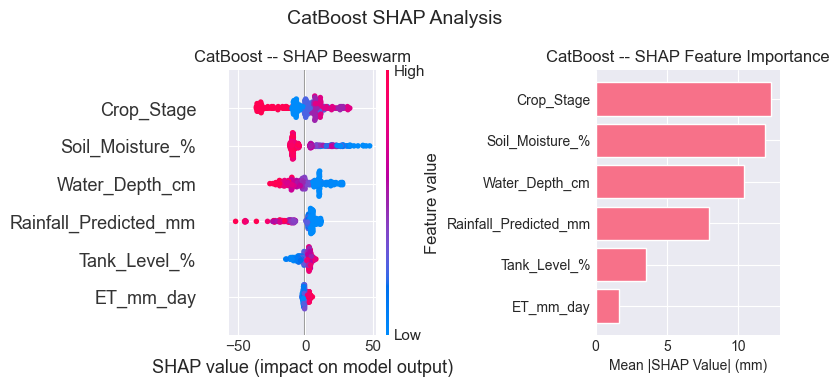

Saved: shap_catboost_summary.png

CatBoost SHAP Feature Importance:
Rank   Feature                    Mean |SHAP|
---------------------------------------------
1      Crop_Stage                     12.3090
2      Soil_Moisture_%                11.8834
3      Water_Depth_cm                 10.4317
4      Rainfall_Predicted_mm           7.9151
5      Tank_Level_%                    3.5441
6      ET_mm_day                       1.6214


In [36]:
# ============================================================
# Cell 7.2 - CatBoost SHAP Beeswarm and Importance Bar Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Beeswarm Plot ---
plt.sca(axes[0])
shap.summary_plot(
    shap_values_cat,
    X_test,
    feature_names=feature_columns,
    show=False
)
axes[0].set_title("CatBoost -- SHAP Beeswarm", fontsize=12)

# --- Importance Bar Plot ---
shap_importance_cat = pd.DataFrame({
    'Feature': feature_columns,
    'Mean_Abs_SHAP': np.abs(shap_values_cat).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

axes[1].barh(
    shap_importance_cat['Feature'][::-1],
    shap_importance_cat['Mean_Abs_SHAP'][::-1]
)
axes[1].set_xlabel('Mean |SHAP Value| (mm)')
axes[1].set_title('CatBoost -- SHAP Feature Importance', fontsize=12)

plt.suptitle('CatBoost SHAP Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('./Visualisation/shap_catboost_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_catboost_summary.png")

# Print importance table
print("\nCatBoost SHAP Feature Importance:")
print(f"{'Rank':<6} {'Feature':<25} {'Mean |SHAP|':>12}")
print("-" * 45)
for i, row in shap_importance_cat.iterrows():
    print(f"{i+1:<6} {row['Feature']:<25} {row['Mean_Abs_SHAP']:>12.4f}")


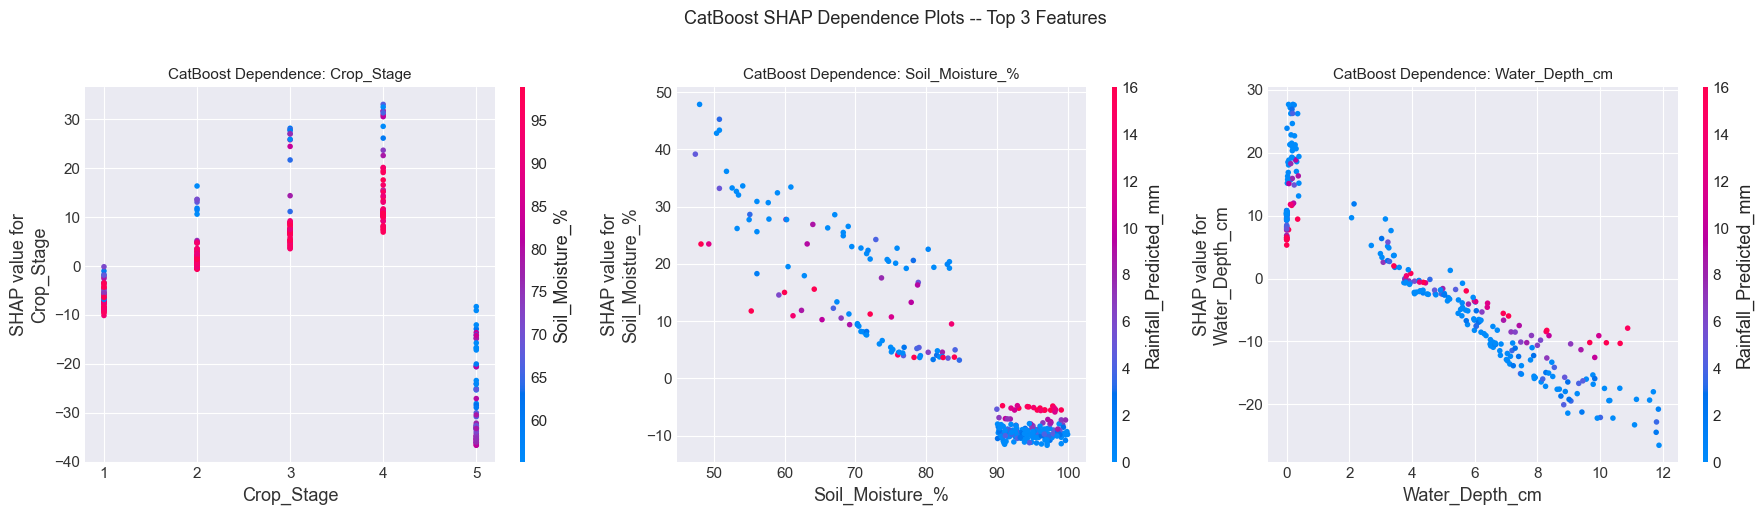

Saved: shap_catboost_dependence.png


In [38]:
# ============================================================
# Cell 7.3 - CatBoost SHAP Dependence Plots (Top 3 Features)
# Shows how each top feature value affects CWR prediction
# ============================================================

top3_cat = shap_importance_cat['Feature'].iloc[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top3_cat):
    feat_idx = feature_columns.index(feature)
    shap.dependence_plot(
        feat_idx,
        shap_values_cat,
        X_test,
        feature_names=feature_columns,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'CatBoost Dependence: {feature}', fontsize=11)

plt.suptitle(
    'CatBoost SHAP Dependence Plots -- Top 3 Features',
    fontsize=13,
    y=1.02
)
plt.tight_layout()
plt.savefig('./Visualisation/shap_catboost_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_catboost_dependence.png")


In [39]:
# ============================================================
# Cell 7.4 - Hybrid Stack SHAP Values via KernelExplainer
# Treats the full hybrid pipeline as a black box
# Explains final CWR output in terms of original 6 features
# Background: 100 kmeans summary samples (standard practice)
# Explained : 100 test samples (KernelExplainer is slow)
# ============================================================

print("=" * 60)
print("Part B: Hybrid Stack -- KernelExplainer (black-box)")
print("-" * 60)
print("Note: KernelExplainer is slow by design.")
print("      Using 100 background samples + 100 explained samples.")
print("      Estimated time: 3 to 10 minutes depending on hardware.")
print("-" * 60)

# Full hybrid stack prediction function
# Accepts raw feature DataFrame, returns final ensemble prediction
def hybrid_predict(X_input):
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=feature_columns)
    preds = np.zeros((len(X_input), 3))
    for champ_idx, (champion_retrained, _) in enumerate(retrained_champions):
        preds[:, champ_idx] = champion_retrained.predict(X_input)
    return meta_learner.predict(preds)

# Background dataset -- 100 kmeans cluster centres from training set
background = shap.kmeans(X_train, 100)

# Subset of test set to explain -- 100 samples for speed
X_test_subset = X_test.iloc[:100].reset_index(drop=True)

explainer_hybrid = shap.KernelExplainer(hybrid_predict, background)

print("Running KernelExplainer...")
start_time = time.time()
shap_values_hybrid = explainer_hybrid.shap_values(X_test_subset, nsamples=256)
kernel_time = time.time() - start_time

print(f"\nHybrid Stack SHAP values computed successfully.")
print(f"Time taken        : {kernel_time:.1f}s")
print(f"SHAP values shape : {shap_values_hybrid.shape}")


Part B: Hybrid Stack -- KernelExplainer (black-box)
------------------------------------------------------------
Note: KernelExplainer is slow by design.
      Using 100 background samples + 100 explained samples.
      Estimated time: 3 to 10 minutes depending on hardware.
------------------------------------------------------------
Running KernelExplainer...


  0%|          | 0/100 [00:00<?, ?it/s]


Hybrid Stack SHAP values computed successfully.
Time taken        : 42.7s
SHAP values shape : (100, 6)


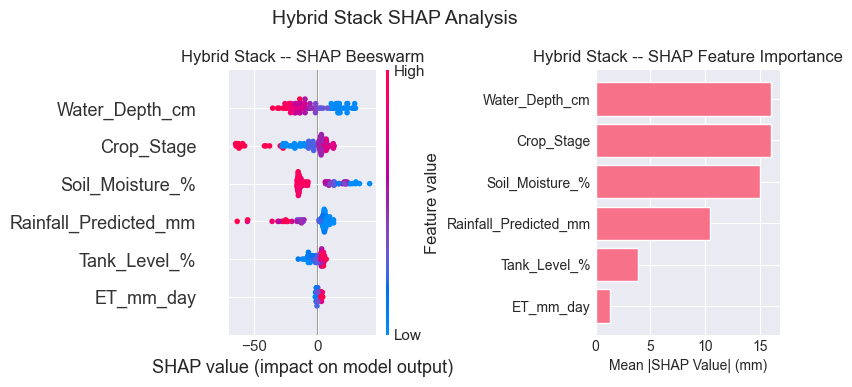

Saved: shap_hybrid_summary.png

Hybrid Stack SHAP Feature Importance:
Rank   Feature                    Mean |SHAP|
---------------------------------------------
1      Water_Depth_cm                 16.0172
2      Crop_Stage                     16.0036
3      Soil_Moisture_%                14.9992
4      Rainfall_Predicted_mm          10.4734
5      Tank_Level_%                    3.8281
6      ET_mm_day                       1.3143


In [40]:
# ============================================================
# Cell 7.5 - Hybrid Stack SHAP Beeswarm and Importance Bar
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Beeswarm Plot ---
plt.sca(axes[0])
shap.summary_plot(
    shap_values_hybrid,
    X_test_subset,
    feature_names=feature_columns,
    show=False
)
axes[0].set_title("Hybrid Stack -- SHAP Beeswarm", fontsize=12)

# --- Importance Bar Plot ---
shap_importance_hybrid = pd.DataFrame({
    'Feature': feature_columns,
    'Mean_Abs_SHAP': np.abs(shap_values_hybrid).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

axes[1].barh(
    shap_importance_hybrid['Feature'][::-1],
    shap_importance_hybrid['Mean_Abs_SHAP'][::-1]
)
axes[1].set_xlabel('Mean |SHAP Value| (mm)')
axes[1].set_title('Hybrid Stack -- SHAP Feature Importance', fontsize=12)

plt.suptitle('Hybrid Stack SHAP Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('./Visualisation/shap_hybrid_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_hybrid_summary.png")

# Print importance table
print("\nHybrid Stack SHAP Feature Importance:")
print(f"{'Rank':<6} {'Feature':<25} {'Mean |SHAP|':>12}")
print("-" * 45)
for i, row in shap_importance_hybrid.iterrows():
    print(f"{i+1:<6} {row['Feature']:<25} {row['Mean_Abs_SHAP']:>12.4f}")


SHAP FEATURE IMPORTANCE COMPARISON
Feature                       CatBoost   Hybrid Stack
-------------------------------------------------------
Crop_Stage                     12.3090        16.0036
Soil_Moisture_%                11.8834        14.9992
Water_Depth_cm                 10.4317        16.0172
Rainfall_Predicted_mm           7.9151        10.4734
Tank_Level_%                    3.5441         3.8281
ET_mm_day                       1.6214         1.3143


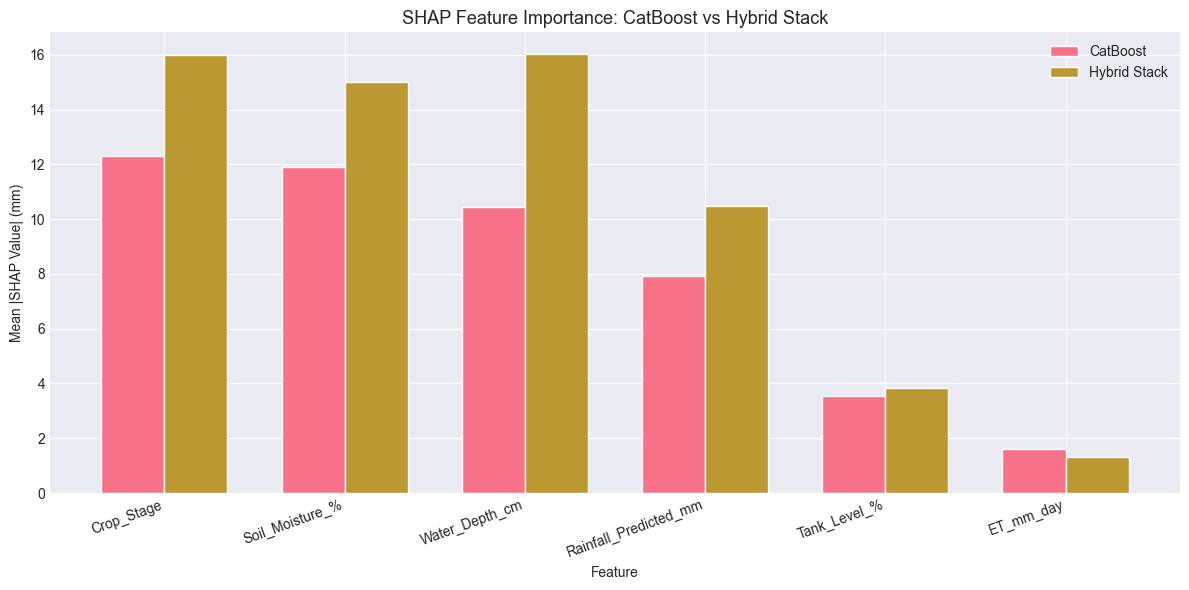

Saved: shap_comparison.png


In [41]:
# ============================================================
# Cell 7.6 - Feature Importance Comparison
# CatBoost SHAP vs Hybrid Stack SHAP
# Reveals whether ensemble blending shifts feature reliance
# ============================================================

comparison_df = pd.DataFrame({
    'Feature':        feature_columns,
    'CatBoost_SHAP':  np.abs(shap_values_cat).mean(axis=0),
    'HybridStack_SHAP': np.abs(shap_values_hybrid).mean(axis=0)
}).sort_values('CatBoost_SHAP', ascending=False).reset_index(drop=True)

print("=" * 60)
print("SHAP FEATURE IMPORTANCE COMPARISON")
print("=" * 60)
print(f"{'Feature':<25} {'CatBoost':>12} {'Hybrid Stack':>14}")
print("-" * 55)
for _, row in comparison_df.iterrows():
    print(f"{row['Feature']:<25} {row['CatBoost_SHAP']:>12.4f} "
          f"{row['HybridStack_SHAP']:>14.4f}")

# Side-by-side bar chart
x     = np.arange(len(feature_columns))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, comparison_df['CatBoost_SHAP'],
               width, label='CatBoost')
bars2 = ax.bar(x + width/2, comparison_df['HybridStack_SHAP'],
               width, label='Hybrid Stack')

ax.set_xlabel('Feature')
ax.set_ylabel('Mean |SHAP Value| (mm)')
ax.set_title('SHAP Feature Importance: CatBoost vs Hybrid Stack', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Feature'], rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('./Visualisation/shap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_comparison.png")


In [42]:
# ============================================================
# Cell 7.7 - SHAP Monotonicity Validation
# Verifies SHAP directions align with FAO-56 constraints
# Validated for both CatBoost and Hybrid Stack
# Constraint directions:
#   Water_Depth_cm       (-1) --> negative SHAP correlation
#   Soil_Moisture_%      (-1) --> negative SHAP correlation
#   ET_mm_day            (+1) --> positive SHAP correlation
#   Rainfall_Predicted_mm(-1) --> negative SHAP correlation
# ============================================================

constrained_features_shap = {
    'Water_Depth_cm':        -1,
    'Soil_Moisture_%':       -1,
    'ET_mm_day':             +1,
    'Rainfall_Predicted_mm': -1,
}

def validate_monotonicity(shap_vals, X_data, label):
    print(f"\n{label}")
    print(f"{'Feature':<25} {'Expected':>10} {'Correlation':>12} {'Status':>8}")
    print("-" * 60)
    all_passed = True
    for feature, expected_direction in constrained_features_shap.items():
        feat_idx     = feature_columns.index(feature)
        feature_vals = X_data[feature].values
        shap_col     = shap_vals[:, feat_idx]
        correlation  = np.corrcoef(feature_vals, shap_col)[0, 1]

        if expected_direction == +1:
            passed       = correlation > 0
            expected_str = 'Positive'
        else:
            passed       = correlation < 0
            expected_str = 'Negative'

        status = 'PASS' if passed else 'FAIL'
        if not passed:
            all_passed = False

        print(f"{feature:<25} {expected_str:>10} {correlation:>12.4f} {status:>8}")

    print("-" * 60)
    if all_passed:
        print(f"All FAO-56 constraints validated for {label}.")
    else:
        print(f"Warning: One or more constraints failed for {label}.")

print("=" * 60)
print("SHAP MONOTONICITY VALIDATION -- FAO-56 COMPLIANCE")
print("=" * 60)

# Validate CatBoost -- uses full test set
validate_monotonicity(shap_values_cat, X_test, "CatBoost (600 test samples)")

# Validate Hybrid Stack -- uses 100-sample subset
validate_monotonicity(shap_values_hybrid, X_test_subset, "Hybrid Stack (100 test samples)")

print("\nSHAP analysis complete.")


SHAP MONOTONICITY VALIDATION -- FAO-56 COMPLIANCE

CatBoost (600 test samples)
Feature                     Expected  Correlation   Status
------------------------------------------------------------
Water_Depth_cm              Negative      -0.9340     PASS
Soil_Moisture_%             Negative      -0.9295     PASS
ET_mm_day                   Positive       0.9562     PASS
Rainfall_Predicted_mm       Negative      -0.8786     PASS
------------------------------------------------------------
All FAO-56 constraints validated for CatBoost (600 test samples).

Hybrid Stack (100 test samples)
Feature                     Expected  Correlation   Status
------------------------------------------------------------
Water_Depth_cm              Negative      -0.9595     PASS
Soil_Moisture_%             Negative      -0.9272     PASS
ET_mm_day                   Positive       0.9635     PASS
Rainfall_Predicted_mm       Negative      -0.9009     PASS
-------------------------------------------------

# Step 8  Model Persistence

In [43]:
# ============================================================
# STEP 8 - MODEL PERSISTENCE
# Cell 8.1 - Save All Champions and Hybrid Stack Artefacts
# Fixed filenames -- reruns overwrite existing files
# ============================================================

import joblib
import os

# Create directories if they do not exist
models_dir    = './Models'
retrained_dir = './Models/retrained'
os.makedirs(models_dir,    exist_ok=True)
os.makedirs(retrained_dir, exist_ok=True)

print("=" * 60)
print("STEP 8 - MODEL PERSISTENCE")
print("=" * 60)
print(f"Save directory : {models_dir}")
print("-" * 60)

# --- Save Family Champions ---
family1_path = f"{models_dir}/family1_champion_{family1_champion_name.lower().replace(' ', '_')}.pkl"
family2_path = f"{models_dir}/family2_champion_{family2_champion_name.lower().replace(' ', '_')}.pkl"
family3_path = f"{models_dir}/family3_champion_{family3_champion_name.lower().replace(' ', '_')}.pkl"

joblib.dump(family1_champion, family1_path)
joblib.dump(family2_champion, family2_path)
joblib.dump(family3_champion, family3_path)

print(f"Family 1 Champion saved : {family1_path}")
print(f"Family 2 Champion saved : {family2_path}")
print(f"Family 3 Champion saved : {family3_path}")

# --- Save Retrained Champions (used for inference) ---
for champ_idx, (champion_retrained, champ_name) in enumerate(retrained_champions):
    retrained_path = f"{retrained_dir}/retrained_family{champ_idx + 1}_{champ_name.lower().replace(' ', '_')}.pkl"
    joblib.dump(champion_retrained, retrained_path)
    print(f"Retrained champion saved : {retrained_path}")

# --- Save Meta-Learner ---
meta_path = f"{models_dir}/meta_learner_ridge.pkl"
joblib.dump(meta_learner, meta_path)
print(f"Meta-learner saved       : {meta_path}")

print("\nAll models saved successfully.")


STEP 8 - MODEL PERSISTENCE
Save directory : ./Models
------------------------------------------------------------
Family 1 Champion saved : ./Models/family1_champion_catboost.pkl
Family 2 Champion saved : ./Models/family2_champion_svr.pkl
Family 3 Champion saved : ./Models/family3_champion_mlp.pkl
Retrained champion saved : ./Models/retrained/retrained_family1_catboost.pkl
Retrained champion saved : ./Models/retrained/retrained_family2_svr.pkl
Retrained champion saved : ./Models/retrained/retrained_family3_mlp.pkl
Meta-learner saved       : ./Models/meta_learner_ridge.pkl

All models saved successfully.


In [44]:
# ============================================================
# Cell 8.2 - Save Meta-Feature Matrices
# Fixed filenames -- reruns overwrite existing files
# ============================================================

import numpy as np

meta_features_dir = './Models/meta_features'
os.makedirs(meta_features_dir, exist_ok=True)

z_train_path = f"{meta_features_dir}/Z_train.npy"
z_test_path  = f"{meta_features_dir}/Z_test.npy"

np.save(z_train_path, Z_train)
np.save(z_test_path,  Z_test)

print("=" * 60)
print("META-FEATURE MATRICES SAVED")
print("=" * 60)
print(f"Z_train saved : {z_train_path}  shape: {Z_train.shape}")
print(f"Z_test  saved : {z_test_path}   shape: {Z_test.shape}")
print("\nThese matrices serve as:")
print("  Z_train --> meta-learner training input (OOF predictions)")
print("  Z_test  --> meta-learner evaluation input")
print("  Both reusable in Phase 3 knowledge distillation pipeline")


META-FEATURE MATRICES SAVED
Z_train saved : ./Models/meta_features/Z_train.npy  shape: (1400, 3)
Z_test  saved : ./Models/meta_features/Z_test.npy   shape: (300, 3)

These matrices serve as:
  Z_train --> meta-learner training input (OOF predictions)
  Z_test  --> meta-learner evaluation input
  Both reusable in Phase 3 knowledge distillation pipeline


In [45]:
# ============================================================
# Cell 8.3 - Save Experiment Configuration and Results
# Fixed filename -- reruns overwrite existing log
# ============================================================

import json

experiment_log = {
    'random_state': RANDOM_STATE,
    'dataset': {
        'total_samples': len(X),
        'train_samples': len(X_train),
        'val_samples':   len(X_val),
        'test_samples':  len(X_test),
        'features':      feature_columns,
        'target':        target_column
    },
    'monotonic_constraints': {
        'Water_Depth_cm':        -1,
        'Soil_Moisture_%':       -1,
        'Tank_Level_%':           0,
        'ET_mm_day':             +1,
        'Rainfall_Predicted_mm': -1,
        'Crop_Stage':             0
    },
    'family1': {
        'champion': family1_champion_name,
        'val_mae':  round(family1_champion_mae, 4),
        'all_models': {
            name: round(result['val_mae'], 4)
            for name, result in family1_results.items()
        }
    },
    'family2': {
        'champion': family2_champion_name,
        'val_mae':  round(family2_champion_mae, 4),
        'all_models': {
            name: round(result['val_mae'], 4)
            for name, result in family2_results.items()
        }
    },
    'family3': {
        'champion': family3_champion_name,
        'val_mae':  round(family3_champion_mae, 4),
        'architecture': {
            'hidden_layer_sizes': str(hidden_layer_sizes),
            'activation':         best_mlp_params['activation'],
            'learning_rate_init': round(best_mlp_params['learning_rate_init'], 6),
            'learning_rate':      best_mlp_params['learning_rate'],
            'alpha':              round(best_mlp_params['alpha'], 6)
        }
    },
    'meta_learner': {
        'type':       'Ridge',
        'alpha':      round(best_alpha, 6),
        'intercept':  round(float(meta_learner.intercept_), 6),
        'coefficients': {
            name: round(float(coef), 6)
            for name, coef in zip(champion_names, meta_learner.coef_)
        },
        'oof_training_mae': round(meta_oof_mae, 4)
    },
    'test_set_metrics': {
        name: {
            'MAE':  round(compute_metrics(y_test, y_pred, name)['MAE'],  4),
            'RMSE': round(compute_metrics(y_test, y_pred, name)['RMSE'], 4),
            'R2':   round(compute_metrics(y_test, y_pred, name)['R2'],   4)
        }
        for name, y_pred in zip(
            [family1_champion_name, family2_champion_name,
             family3_champion_name, 'Hybrid Stack'],
            [y_pred_family1, y_pred_family2,
             y_pred_family3, y_pred_hybrid]
        )
    },
    'rule_violation': {
        feature: round(rate, 4)
        for feature, rate in violation_results.items()
    },
    'overall_rule_violation_rate': round(overall_violation_rate, 4),
    'shap': {
        'catboost_top_features':     shap_importance_cat['Feature'].tolist(),
        'hybrid_stack_top_features': shap_importance_hybrid['Feature'].tolist()
    },
    'saved_files': {
        'family1_champion': family1_path,
        'family2_champion': family2_path,
        'family3_champion': family3_path,
        'meta_learner':     meta_path,
        'Z_train':          z_train_path,
        'Z_test':           z_test_path
    }
}

log_path = f"{models_dir}/experiment_log.json"
with open(log_path, 'w') as f:
    json.dump(experiment_log, f, indent=4)

print("=" * 60)
print("EXPERIMENT LOG SAVED")
print("=" * 60)
print(f"Log file : {log_path}")
print("\nLog contents:")
print(json.dumps(experiment_log, indent=4))


EXPERIMENT LOG SAVED
Log file : ./Models/experiment_log.json

Log contents:
{
    "random_state": 42,
    "dataset": {
        "total_samples": 2000,
        "train_samples": 1400,
        "val_samples": 300,
        "test_samples": 300,
        "features": [
            "Water_Depth_cm",
            "Soil_Moisture_%",
            "Tank_Level_%",
            "ET_mm_day",
            "Rainfall_Predicted_mm",
            "Crop_Stage"
        ],
        "target": "CWR_mm"
    },
    "monotonic_constraints": {
        "Water_Depth_cm": -1,
        "Soil_Moisture_%": -1,
        "Tank_Level_%": 0,
        "ET_mm_day": 1,
        "Rainfall_Predicted_mm": -1,
        "Crop_Stage": 0
    },
    "family1": {
        "champion": "CatBoost",
        "val_mae": 1.4799,
        "all_models": {
            "Random Forest": 2.1481,
            "Gradient Boosting": 1.6564,
            "XGBoost": 4.1404,
            "LightGBM": 3.8562,
            "CatBoost": 1.4799
        }
    },
    "family2": {
  

In [46]:
# ============================================================
# Cell 8.4 - Verify All Saved Files
# Confirms all artefacts exist and are loadable
# ============================================================

print("=" * 60)
print("STEP 8.4 - SAVED FILE VERIFICATION")
print("=" * 60)

files_to_verify = [
    family1_path,
    family2_path,
    family3_path,
    meta_path,
    z_train_path,
    z_test_path,
    log_path
]

all_verified = True

for filepath in files_to_verify:
    exists  = os.path.exists(filepath)
    size_kb = os.path.getsize(filepath) / 1024 if exists else 0
    status  = 'OK' if exists else 'MISSING'
    if not exists:
        all_verified = False
    print(f"{status:<8} {size_kb:>8.1f} KB   {filepath}")

print("-" * 60)
if all_verified:
    print("\nAll artefacts verified successfully.")
    print("Phase 2 -- Hybrid Stacking Ensemble is complete.")
    print("\nArtefacts ready for Phase 3:")
    print("  - Retrained family champions (base learners)")
    print("  - Ridge meta-learner")
    print("  - Z_train and Z_test meta-feature matrices")
    print("  - Experiment log (full reproducibility record)")
else:
    print("\nWarning: Some files are missing. Re-run the affected cells.")


STEP 8.4 - SAVED FILE VERIFICATION
OK         2054.4 KB   ./Models/family1_champion_catboost.pkl
OK           94.0 KB   ./Models/family2_champion_svr.pkl
OK          204.7 KB   ./Models/family3_champion_mlp.pkl
OK            0.6 KB   ./Models/meta_learner_ridge.pkl
OK           32.9 KB   ./Models/meta_features/Z_train.npy
OK            7.2 KB   ./Models/meta_features/Z_test.npy
OK            3.3 KB   ./Models/experiment_log.json
------------------------------------------------------------

All artefacts verified successfully.
Phase 2 -- Hybrid Stacking Ensemble is complete.

Artefacts ready for Phase 3:
  - Retrained family champions (base learners)
  - Ridge meta-learner
  - Z_train and Z_test meta-feature matrices
  - Experiment log (full reproducibility record)
